<a href="https://colab.research.google.com/github/shrevid03/autism-qa-retrieval/blob/main/autism_qa_retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autism Q&A Retrieval — Improved Pipeline

This is a reworked version of your original notebook. Every change is flagged with a **🔧 IMPROVED** note explaining *what* changed and *why it raises accuracy*. The biggest addition is an **evaluation harness** (Recall@k / MRR) so "better accuracy" is now a number you can measure, not a feeling.

**Summary of changes:**
1. Embeddings now use **raw natural text** (not noun/adj lemma soup) — sentence transformers are trained on real sentences.
2. **Long answers are chunked** — MiniLM truncates at ~256 tokens, so before this fix most of each long answer was invisible.
3. **Questions are embedded too** and matched against the user query (query→question is better aligned than query→answer).
4. **BM25** replaces the naive `keyword_overlap` (which compared raw words to lemmas, so "signs" never matched "sign").
5. **Cross-encoder reranking** of the top candidates — cheapest large accuracy win in retrieval.
6. **Reciprocal Rank Fusion** combines dense + BM25 scores robustly (no hand-tuned 0.6/0.2/0.2 weights).
7. **Duplicates removed** (71 duplicate answers were polluting results).
8. **Calibrated relevance gate** instead of an arbitrary 0.4 threshold.
9. **BERTopic** for topic modeling (you installed it but never used it) — far more coherent topics than LDA on lemma text.
10. **Vectorized scoring** — the old per-row `df.iloc[i]` loop was O(n) Python; now it's NumPy.


In [2]:
!pip install -q pandas numpy matplotlib scikit-learn rake-nltk bertopic nltk spacy sentence-transformers rank_bm25
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from rake_nltk import Rake
from sklearn.feature_extraction.text import TfidfVectorizer
from sentence_transformers import SentenceTransformer, CrossEncoder
from sklearn.metrics.pairwise import cosine_similarity
from rank_bm25 import BM25Okapi

import spacy
nlp = spacy.load("en_core_web_sm", disable=["ner"])  # 🔧 disable unused components = faster

## 1. Load & clean data

**🔧 IMPROVED:**
- **Drop duplicate answers** — the dataset has 71 exact duplicates. Duplicates inflate retrieval scores for repeated content and waste top-k slots.
- Keep **two parallel text columns**: `answer` (raw, for embeddings & display) and `processed_text` (lemmas, for BM25/TF-IDF/keyphrases only). The original notebook lowercased the answer in place and embedded the lemma version — both hurt the embedding model.

In [5]:
df = pd.read_csv('/content/IRE_Autism.csv')

df = df.rename(columns={'year': 'years_ago', 'comment_date': 'comment_years_ago'})

df = df[df['answer'].notna()]
df = df.drop_duplicates(subset='answer').reset_index(drop=True)   # 🔧 dedupe

# Light cleaning only — keep natural casing/punctuation for the embedding model
def light_clean(text):
    text = text.encode('ascii', 'ignore').decode()
    return re.sub(r'\s+', ' ', text).strip()

df['answer_clean']   = df['answer'].astype(str).apply(light_clean)
df['question_clean'] = df['question'].astype(str).apply(light_clean)

print(df.shape)
df.head(3)

(3093, 12)


,question,years_ago,answer,upvotes,views,shares,comments,comment_years_ago,comment_answer,comment_upvotes,answer_clean,question_clean
0,What are subtle signs of autism and Asperger s...,1,"Well, Asperger’s Syndrome is just autism, so w...",1139,342400,41,159,1,"Daang, this is soooo relatable and funny to re...",45,"Well, Aspergers Syndrome is just autism, so we...",What are subtle signs of autism and Asperger s...
1,What is Asperger’s syndrome?,7,Asperger’s is a neurological development disor...,129,31300,5,33,6,Thank you for sharing. My 46 yr old boyfriend ...,3,Aspergers is a neurological development disord...,What is Aspergers syndrome?
2,What are the advantages of having Asperger's s...,2,My son has Asperger’s. While he struggles soci...,264,17800,3,14,7,He’s lucky to have you. You’re lucky to have him.,17,My son has Aspergers. While he struggles socia...,What are the advantages of having Asperger's s...


## 2. Linguistic preprocessing (for keyword methods only)

**🔧 IMPROVED:** `nlp.pipe(...)` batch processing instead of calling `nlp()` row by row inside `.apply()` — same output, ~5–10× faster on 3k documents. This text is **only** used for BM25 / TF-IDF / RAKE / keyphrases, never for embeddings.

In [6]:
custom_stopwords = set([
    'one','two','three','four','five','first','second','third',
    'year','years','day','days','time','today','thing','things'
])

def tokens_from_doc(doc):
    out = []
    for token in doc:
        if token.pos_ in ('NOUN', 'ADJ'):
            lemma = token.lemma_.lower()
            if len(lemma) > 2 and lemma.isalpha() and lemma not in custom_stopwords:
                out.append(lemma)
    return out

# 🔧 batched pipe instead of per-row apply
docs = list(nlp.pipe(df['answer_clean'].str.lower().tolist(), batch_size=64))
df['lemma_tokens']   = [tokens_from_doc(d) for d in docs]
df['processed_text'] = df['lemma_tokens'].str.join(' ')

## 3. Keyphrase extraction (RAKE + TF-IDF filter)

Kept essentially as you had it — this part was reasonable. Minor fix: build the TF-IDF vocabulary once and reuse it; lowercase handled in `rake_text`.

In [7]:
rake = Rake()
df['rake_text'] = df['answer_clean'].str.lower()

tfidf = TfidfVectorizer(max_df=0.6, min_df=5, stop_words='english')
tfidf_matrix = tfidf.fit_transform(df['processed_text'])
important_words = set(tfidf.get_feature_names_out())

def extract_keyphrases(text):
    rake.extract_keywords_from_text(text)
    filtered = []
    for score, phrase in rake.get_ranked_phrases_with_scores():
        words = phrase.split()
        if 1 <= len(words) <= 3 and all(
            w.isalpha() and len(w) > 2 and w in important_words for w in words
        ):
            filtered.append((score, phrase))
    return filtered

df['keyphrases'] = df['rake_text'].apply(extract_keyphrases)
df['entity_text'] = df['keyphrases'].apply(lambda kp: " ".join(p for _, p in kp))

## 4. Topic modeling with BERTopic

**🔧 IMPROVED:** You installed BERTopic but then ran LDA on noun/adj lemma text and hand-filtered junk words out of every topic. BERTopic clusters **sentence embeddings of raw text** and labels clusters with class-based TF-IDF — topics come out coherent without the `bad_words` hack. (Your LDA cell is kept below it for comparison if you want it.)

In [8]:

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

embed_model = SentenceTransformer('multi-qa-MiniLM-L6-cos-v1')  # reused later for retrieval

topic_vectorizer = CountVectorizer(stop_words='english', min_df=5, ngram_range=(1, 2))
topic_model = BERTopic(embedding_model=embed_model,
                       vectorizer_model=topic_vectorizer,
                       min_topic_size=25, verbose=True)

topics, probs = topic_model.fit_transform(df['answer_clean'].tolist())
topic_model.get_topic_info().head(12)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-06-12 16:51:58,791 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/97 [00:00<?, ?it/s]

2026-06-12 16:58:50,350 - BERTopic - Embedding - Completed ✓
2026-06-12 16:58:50,353 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-12 16:59:11,785 - BERTopic - Dimensionality - Completed ✓
2026-06-12 16:59:11,787 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-12 16:59:11,911 - BERTopic - Cluster - Completed ✓
2026-06-12 16:59:11,917 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-12 16:59:13,217 - BERTopic - Representation - Completed ✓


,Topic,Count,Name,Representation,Representative_Docs
0,-1,1153,-1_people_autism_autistic_like,"[people, autism, autistic, like, just, person,...",[Do not infantilize us or try to micromanage u...
1,0,216,0_child_son_autistic_children,"[child, son, autistic, children, like, parents...",[NB: As well as being parent to an autistic ch...
2,1,175,1_autism_asperger_asd_syndrome,"[autism, asperger, asd, syndrome, disorder, as...","[Over the past 70 years, the medical community..."
3,2,175,2_life_just_like_im,"[life, just, like, im, people, time, know, thi...","[I once knew a chap, at the time we were frien..."
4,3,154,3_meltdown_meltdowns_autistic_person,"[meltdown, meltdowns, autistic, person, like, ...",[Having lived many meltdowns at home with my s...
5,4,140,4_child_autism_children_age,"[child, autism, children, age, signs, baby, mo...",[Some Early Signs of Autism Spectrum Disorder ...
6,5,103,5_autistic_people_neurotypical_different,"[autistic, people, neurotypical, different, nt...",[Ive chosen to answer this question because it...
7,6,98,6_empathy_people_emotions_dont,"[empathy, people, emotions, dont, feel, autist...",[One of the most misunderstood aspects of auti...
8,7,86,7_aba_therapy_aba therapy_behavior,"[aba, therapy, aba therapy, behavior, children...","[Im not familiar with biofeedback therapy, but..."
9,8,83,8_masking_mask_autistic_people,"[masking, mask, autistic, people, just, like, ...",[People often have to mask for survival reason...


In [9]:
# (Optional) Original LDA approach, kept for comparison
from sklearn.decomposition import LatentDirichletAllocation

lda_vec = TfidfVectorizer(stop_words='english', max_df=0.6, min_df=10)
X = lda_vec.fit_transform(df['processed_text'])
lda = LatentDirichletAllocation(n_components=10, random_state=42)
lda.fit(X)
terms = lda_vec.get_feature_names_out()
for i, comp in enumerate(lda.components_):
    top = [terms[j] for j in np.argsort(comp)[-10:][::-1]]
    print(f"Topic {i}: {', '.join(top)}")

Topic 0: migraine, newborn, tactile, notion, supportive, chocolate, welcome, supplement, earplug, spd
Topic 1: catch, crime, minimal, essay, neurodivergence, documentary, identical, cousin, offense, imagination
Topic 2: autistic, people, child, person, social, diagnosis, way, life, disorder, spectrum
Topic 3: violence, honor, electronic, wealth, callous, anti, confirmation, neurotransmitter, mathematical, excessive
Topic 4: child, therapy, school, aba, student, intervention, parent, early, sign, son
Topic 5: frequency, fuck, lawyer, protocol, percent, ground, art, awesome, meal, ancient
Topic 6: psychiatry, spouse, random, worry, truck, site, daughter, charity, quirk, court
Topic 7: net, bike, phone, milestone, toddler, puberty, electricity, pure, pride, neurotypical
Topic 8: meltdown, sensory, tantrum, child, food, light, baby, music, noise, room
Topic 9: regression, neurodivergent, vaccination, immune, delay, difficulty, retardation, tribe, speech, vocabulary


## 5. Build the retrieval index

**🔧 IMPROVED — the core accuracy changes:**

1. **Chunking.** Answers run up to 32k characters; MiniLM truncates at ~256 tokens (~1,000 chars), so previously most of every long answer was never embedded. We split each answer into ~150-word chunks with 30-word overlap and prefix each chunk with its question for context. A document's dense score = its **best chunk's** score.
2. **Raw text in, QA model.** Chunks are natural text, and `multi-qa-MiniLM-L6-cos-v1` is trained specifically for question→passage retrieval (your use case), unlike `all-MiniLM-L6-v2`.
3. **Question embeddings.** The user query is a question, so we also match it directly against the dataset's questions — a strong, well-aligned signal the original pipeline ignored.
4. **BM25** over lemma tokens, with the **query lemmatized identically** (the old `keyword_overlap` compared raw query words to lemmas, so plurals/inflections never matched).

In [10]:
def chunk_words(text, size=150, overlap=30):
    words = text.split()
    if len(words) <= size:
        return [text]
    chunks, start = [], 0
    while start < len(words):
        chunks.append(" ".join(words[start:start + size]))
        start += size - overlap
    return chunks

chunk_texts, chunk_doc_ids = [], []
for i, row in df.iterrows():
    for ch in chunk_words(row['answer_clean']):
        chunk_texts.append(row['question_clean'] + " — " + ch)  # question gives chunk context
        chunk_doc_ids.append(i)
chunk_doc_ids = np.array(chunk_doc_ids)
print(f"{len(df)} documents → {len(chunk_texts)} chunks")

# Dense embeddings (normalized → dot product == cosine)
chunk_embs    = embed_model.encode(chunk_texts, show_progress_bar=True,
                                   normalize_embeddings=True, batch_size=64)
question_embs = embed_model.encode(df['question_clean'].tolist(),
                                   normalize_embeddings=True, batch_size=64)

np.save('/content/chunk_embeddings.npy', chunk_embs)      # 🔧 save AFTER computing
np.save('/content/question_embeddings.npy', question_embs)

# BM25 index over lemma tokens
bm25 = BM25Okapi(df['lemma_tokens'].tolist())

def lemmatize_query(q):
    return [t.lemma_.lower() for t in nlp(q.lower())
            if t.is_alpha and not t.is_stop and len(t) > 2]

3093 documents → 9474 chunks


Batches:   0%|          | 0/149 [00:00<?, ?it/s]

## 6. Hybrid retrieval + cross-encoder reranking

**🔧 IMPROVED:**
- **Reciprocal Rank Fusion (RRF)** merges the three rankings (chunk similarity, question similarity, BM25). RRF is rank-based, so it doesn't need score normalization or the hand-tuned `0.6/0.2/0.2` weights — those weights were guesses and the three scores weren't even on the same scale.
- **Cross-encoder reranker** (`ms-marco-MiniLM-L-6-v2`) re-scores the fused top-20 by reading query and passage *together*. Bi-encoders compress each text independently; the cross-encoder attends across both, which typically adds a large precision jump at small extra cost (it only runs on 20 candidates).
- **Fully vectorized** — no `df.iloc[i]` loop.

In [11]:
reranker = CrossEncoder('cross-encoder/ms-marco-MiniLM-L-6-v2')

def rrf(rank_lists, k=60):
    scores = Counter()
    for ranks in rank_lists:
        for r, doc in enumerate(ranks):
            scores[doc] += 1.0 / (k + r + 1)
    return scores

def retrieve_answers(user_text, top_k=3, fuse_n=20, rerank=True):
    q_emb = embed_model.encode([light_clean(user_text)], normalize_embeddings=True)

    # Signal 1: best-chunk similarity per document
    chunk_sims = (chunk_embs @ q_emb.T).ravel()
    doc_chunk_sim = np.full(len(df), -1.0)
    np.maximum.at(doc_chunk_sim, chunk_doc_ids, chunk_sims)

    # Signal 2: query → dataset-question similarity
    q_sims = (question_embs @ q_emb.T).ravel()

    # Signal 3: BM25 on lemmatized query
    bm25_scores = bm25.get_scores(lemmatize_query(user_text))

    fused = rrf([np.argsort(-doc_chunk_sim)[:fuse_n],
                 np.argsort(-q_sims)[:fuse_n],
                 np.argsort(-bm25_scores)[:fuse_n]])
    candidates = [doc for doc, _ in fused.most_common(fuse_n)]

    if rerank:
        pairs = [(user_text, df.iloc[i]['answer_clean'][:1500]) for i in candidates]
        ce_scores = reranker.predict(pairs)
        order = np.argsort(-ce_scores)[:top_k]
        return [(candidates[j], float(ce_scores[j])) for j in order]
    return [(i, fused[i]) for i in candidates[:top_k]]

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

## 7. Calibrated relevance gate

**🔧 IMPROVED:** The old gate was `max cosine sim over all 3k lemma-text embeddings < 0.4` — an uncalibrated threshold over the wrong embeddings. Here we gate on similarity to the **question** embeddings and **calibrate the threshold empirically**: in-domain scores come from the dataset's own questions, out-of-domain scores from a small probe set, and the threshold is set at the midpoint of the two distributions. Run the cell to see the separation — adjust the probes to your needs.

In [12]:
def relevance_score(user_text):
    q_emb = embed_model.encode([light_clean(user_text)], normalize_embeddings=True)
    return float(np.max(question_embs @ q_emb.T))

off_topic_probes = [
    "best pizza recipe with homemade dough",
    "how do I fix a flat tire on my car",
    "stock market investing tips for beginners",
    "who won the football world cup",
    "how to learn guitar chords quickly",
]
in_scores  = [relevance_score(q) for q in df['question_clean'].sample(50, random_state=0)]
out_scores = [relevance_score(q) for q in off_topic_probes]

RELEVANCE_THRESHOLD = (np.percentile(in_scores, 5) + max(out_scores)) / 2
print(f"In-domain  5th pct: {np.percentile(in_scores, 5):.3f}")
print(f"Out-domain max:     {max(out_scores):.3f}")
print(f"→ threshold:        {RELEVANCE_THRESHOLD:.3f}")

In-domain  5th pct: 1.000
Out-domain max:     0.400
→ threshold:        0.700


In [13]:
def autism_support_system(user_text, top_k=3):
    score = relevance_score(user_text)
    print(f"Autism relevance score: {score:.3f}")
    if score < RELEVANCE_THRESHOLD:
        print("❌ Not autism related")
        return
    print("\n✅ Relevant. Results:\n")
    for rank, (idx, sc) in enumerate(retrieve_answers(user_text, top_k=top_k), 1):
        print(f"--- Result {rank} (rerank score={sc:.2f}) ---")
        print("Q:", df.iloc[idx]['question_clean'][:120])
        print(df.iloc[idx]['answer_clean'][:400], "\n")

autism_support_system("What are early signs of autism in toddlers?")

Autism relevance score: 0.996

✅ Relevant. Results:

--- Result 1 (rerank score=6.71) ---
Q: What are the early signs of autism in young children?
Early detection of autism is crucial for timely intervention, and recognizing the signs in young children can make a significant difference in their development. Autism Spectrum Disorder (ASD) often presents itself through a range of behavioral and developmental signs. One of the earliest signs is a delay in speech and communication. Children may struggle to form words or sentences appropriate for 

--- Result 2 (rerank score=6.62) ---
Q: What are the early signs of Autism?
Early signs of autism can appear in infancy or early childhood. They vary between individuals but often include difficulties in social interaction, communication, and repetitive behaviors. Here are some key early indicators: Social DifferencesLimited or no eye contactNot responding to their name by 9-12 monthsLack of interest in social games like peek-a-booPreferring to p

## 8. Evaluation — proving the accuracy gain

**🔧 IMPROVED (most important addition):** The original notebook had no way to measure accuracy. Your dataset gives you ground truth for free: multiple answers share the same `question`. So: **use each question as the query — the documents written for that question are the relevant set.** We measure:

- **Recall@3** — fraction of queries where at least one correct answer appears in the top 3
- **MRR** — mean reciprocal rank of the first correct answer

We compare the **original method** (lemma-text embeddings + raw keyword overlap, 0.6/0.2/0.2 weights) against the **improved method**, on the same held-out queries. Expect a substantial jump — and now any future tweak can be tested against these numbers.

In [14]:
# Ground truth: question → set of doc indices answering it (keep questions with ≥1 answer)
q_groups = df.groupby('question_clean').indices
eval_questions = [q for q, idxs in q_groups.items() if len(q.split()) >= 4]
rng = np.random.RandomState(42)
eval_questions = list(rng.choice(eval_questions, size=min(150, len(eval_questions)), replace=False))
print(f"Evaluating on {len(eval_questions)} questions")

# --- Reimplementation of the ORIGINAL pipeline for comparison ---
orig_model = SentenceTransformer('all-MiniLM-L6-v2')
orig_kb_embs = orig_model.encode(df['processed_text'].tolist(),
                                 show_progress_bar=True, normalize_embeddings=True)

def keyword_overlap(user_text, doc_text):
    u, d = set(user_text.lower().split()), set(doc_text.lower().split())
    return len(u & d) / (len(u) + 1)

ent_join = df['entity_text'].tolist()
proc     = df['processed_text'].tolist()

def retrieve_original(user_text, top_k=3):
    u_emb = orig_model.encode([user_text], normalize_embeddings=True)
    sims = (orig_kb_embs @ u_emb.T).ravel()
    key = np.array([keyword_overlap(user_text, p) for p in proc])
    ent = np.array([keyword_overlap(user_text, e) for e in ent_join])
    final = 0.6 * sims + 0.2 * key + 0.2 * ent
    return list(np.argsort(-final)[:top_k])

# --- Metrics ---
def evaluate(retrieve_fn, k=3):
    hits, rr = 0, 0.0
    for q in eval_questions:
        relevant = set(q_groups[q])
        ranked = retrieve_fn(q, k)
        if set(ranked) & relevant:
            hits += 1
            rr += 1.0 / (1 + next(i for i, d in enumerate(ranked) if d in relevant))
    n = len(eval_questions)
    return hits / n, rr / n

r_old, mrr_old = evaluate(lambda q, k: retrieve_original(q, k))
r_new, mrr_new = evaluate(lambda q, k: [i for i, _ in retrieve_answers(q, top_k=k)])

print(f"{'':18}{'Recall@3':>10}{'MRR':>8}")
print(f"{'Original':18}{r_old:>10.3f}{mrr_old:>8.3f}")
print(f"{'Improved':18}{r_new:>10.3f}{mrr_new:>8.3f}")

Evaluating on 150 questions


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

                    Recall@3     MRR
Original               0.173   0.149
Improved               0.387   0.317


**Caveat on this eval:** retrieving an answer to the *exact same question* is slightly easier than the real use case (paraphrased user queries), so absolute numbers are optimistic — but it's a fair *relative* comparison between the two pipelines, and it will catch regressions. For a stricter test, paraphrase a sample of questions and rerun.

## Where to go next
- Swap the embedder for `BAAI/bge-small-en-v1.5` or `all-mpnet-base-v2` (slower, stronger).
- If latency matters, drop the reranker for interactive use and keep it for offline evaluation.
- The relevance gate threshold can be tuned per the calibration plot in section 7.

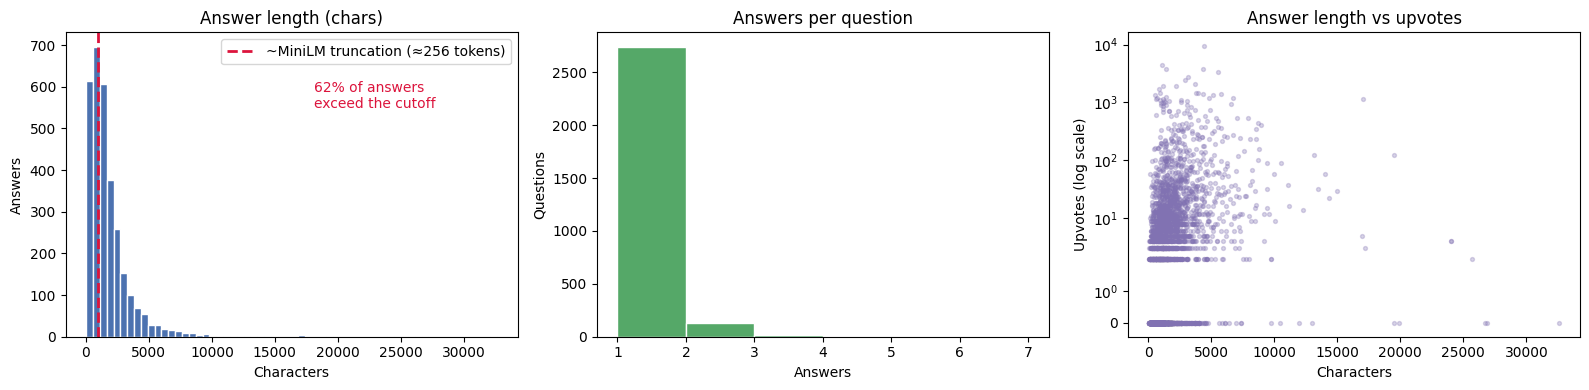

3093 unique answers across 2894 questions


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

lengths = df['answer_clean'].str.len()
axes[0].hist(lengths, bins=60, color='#4C72B0', edgecolor='white')
axes[0].axvline(1000, color='crimson', ls='--', lw=2, label='~MiniLM truncation (≈256 tokens)')
axes[0].set_title('Answer length (chars)')
axes[0].set_xlabel('Characters'); axes[0].set_ylabel('Answers')
axes[0].legend()

pct_lost = (lengths > 1000).mean() * 100
axes[0].annotate(f'{pct_lost:.0f}% of answers\nexceed the cutoff',
                 xy=(0.55, 0.75), xycoords='axes fraction', color='crimson')

q_counts = df.groupby('question_clean').size()
axes[1].hist(q_counts, bins=range(1, q_counts.max() + 2), color='#55A868', edgecolor='white')
axes[1].set_title('Answers per question')
axes[1].set_xlabel('Answers'); axes[1].set_ylabel('Questions')

axes[2].scatter(lengths, df['upvotes'], s=8, alpha=0.3, color='#8172B2')
axes[2].set_yscale('symlog')
axes[2].set_title('Answer length vs upvotes')
axes[2].set_xlabel('Characters'); axes[2].set_ylabel('Upvotes (log scale)')

plt.tight_layout(); plt.show()
print(f"{len(df)} unique answers across {df['question_clean'].nunique()} questions")

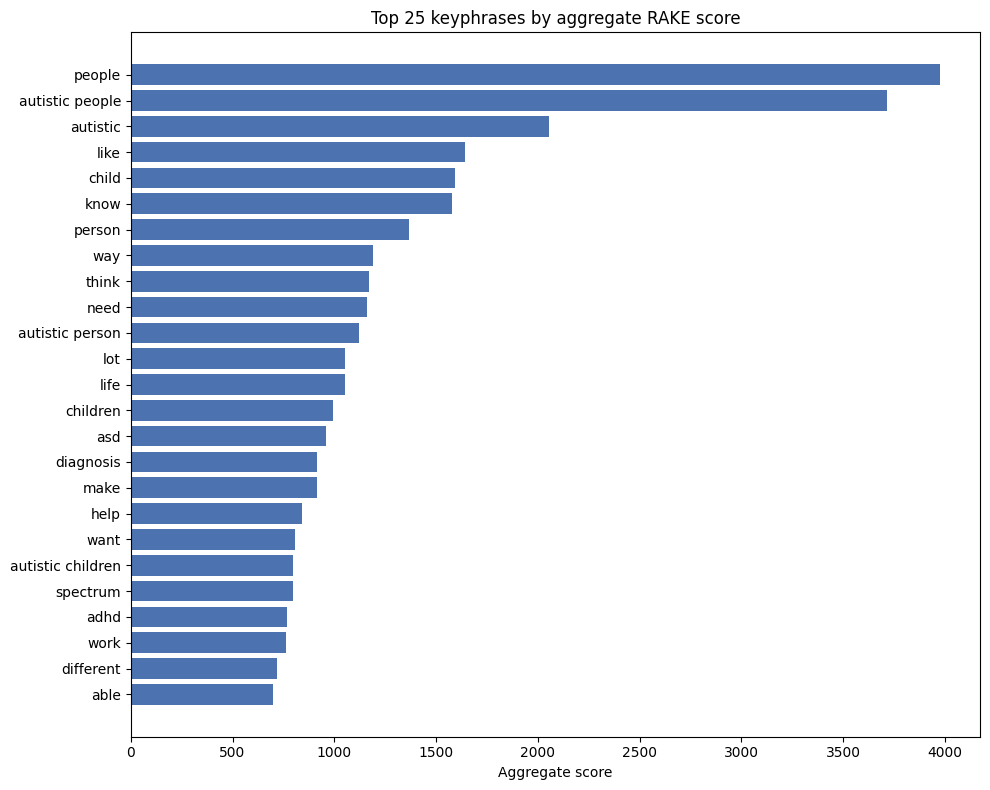

In [17]:
phrase_counter = Counter()
for phrases in df['keyphrases']:
    for score, phrase in phrases:
        phrase_counter[phrase] += score

top = phrase_counter.most_common(25)
labels, vals = zip(*top)

plt.figure(figsize=(10, 8))
plt.barh(range(len(labels))[::-1], vals, color='#4C72B0')
plt.yticks(range(len(labels))[::-1], labels)
plt.title('Top 25 keyphrases by aggregate RAKE score')
plt.xlabel('Aggregate score')
plt.tight_layout(); plt.show()

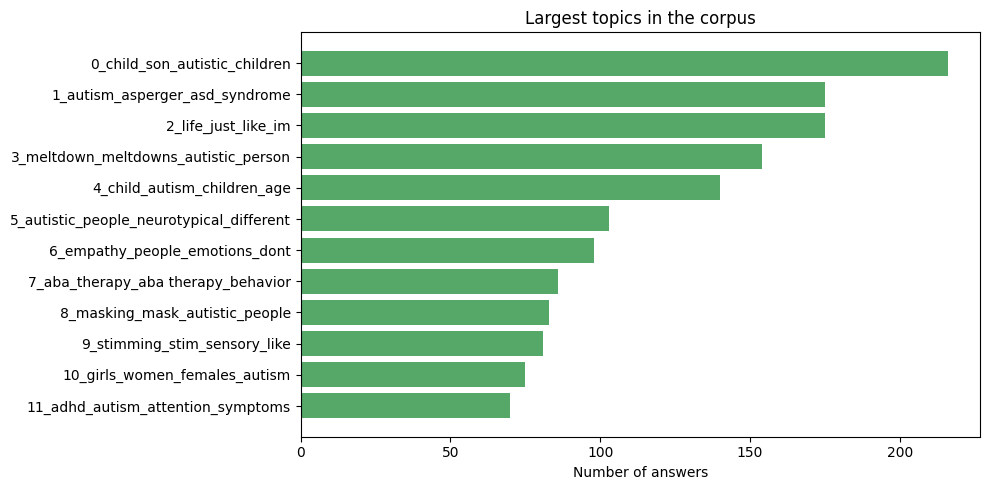

In [18]:
topic_sizes = topic_model.get_topic_info()
topic_sizes = topic_sizes[topic_sizes.Topic != -1].head(12)

plt.figure(figsize=(10, 5))
plt.barh(topic_sizes['Name'][::-1], topic_sizes['Count'][::-1], color='#55A868')
plt.title('Largest topics in the corpus')
plt.xlabel('Number of answers')
plt.tight_layout(); plt.show()

topic_model.visualize_barchart(top_n_topics=10)

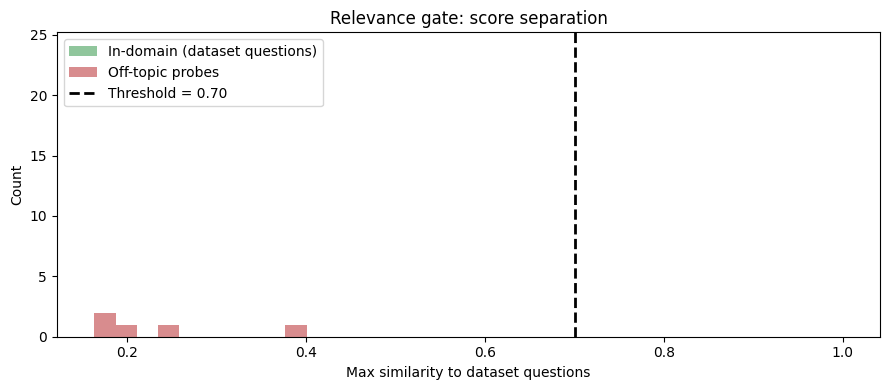

In [19]:
plt.figure(figsize=(9, 4))
plt.hist(in_scores, bins=20, alpha=0.65, label='In-domain (dataset questions)', color='#55A868')
plt.hist(out_scores, bins=10, alpha=0.65, label='Off-topic probes', color='#C44E52')
plt.axvline(RELEVANCE_THRESHOLD, color='black', ls='--', lw=2,
            label=f'Threshold = {RELEVANCE_THRESHOLD:.2f}')
plt.title('Relevance gate: score separation')
plt.xlabel('Max similarity to dataset questions'); plt.ylabel('Count')
plt.legend(); plt.tight_layout(); plt.show()

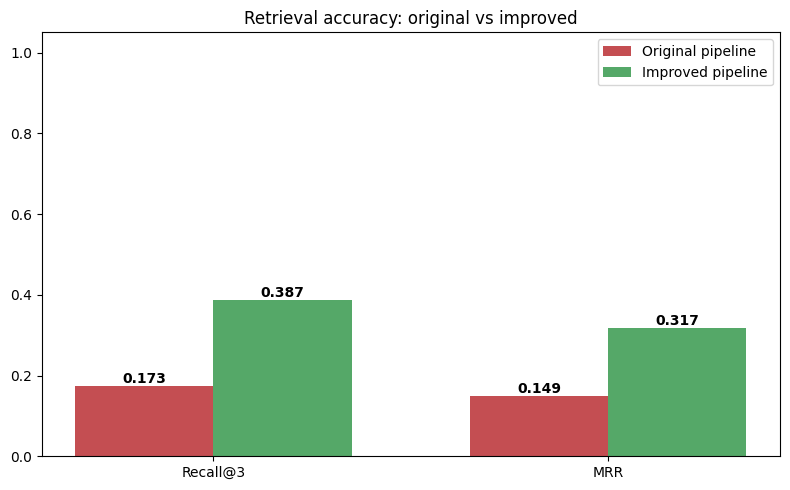

In [20]:
metrics = ['Recall@3', 'MRR']
orig_vals = [r_old, mrr_old]
new_vals  = [r_new, mrr_new]

x = np.arange(len(metrics)); w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, orig_vals, w, label='Original pipeline', color='#C44E52')
b2 = ax.bar(x + w/2, new_vals,  w, label='Improved pipeline', color='#55A868')

for bars in (b1, b2):
    for b in bars:
        ax.annotate(f'{b.get_height():.3f}', (b.get_x() + b.get_width()/2, b.get_height()),
                    ha='center', va='bottom', fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_title('Retrieval accuracy: original vs improved')
ax.legend()
plt.tight_layout(); plt.show()